# 06 - Gap Analysis : Marche IA Maroc vs Curricula ENSA

**Owner** : Bachirou Konate

**Section du rapport L5 alimentee** : Chapitre 5.1 (gap analysis curricula ENSA).

## Objectif

Mesurer le desalignement entre les competences **demandees** par le marche IA / Data Science marocain et international (3 468 fiches collectees par SKILLNAV) et les competences **enseignees** par les 8 filieres Data / IA / Big Data des ENSA publiques marocaines (cycle ingenieur 3 ans, S1 a S5 + PFE).

## Sources de donnees

- **Marche** : `skillnav.analysis.loaders.load_postings()` -> 3 468 postings JSON normalises (Maroc + International).
- **Curricula** : `data/curricula/*.json` produits par le pipeline `skillnav/pipelines/curriculum_mining/` a partir des fichiers `sources/curricula/ensa-*/filiere.md`.

## Definitions des ensembles

- **Set A** = competences enseignees par >= 50 % des ENSA exploitables (>= 4 sur 8 dans la cible, ramene a >= 3 sur 6 pour n = 6 ENSA avec donnees verifiables).
- **Set B** = competences fortement demandees : intersection des top 100 marche **ET** presentes dans >= 10 % des offres.
- **Set C = A intersection B** : competences alignees (bon recouvrement formation <-> marche).
- **Set D = A \ B** : competences sur-enseignees relativement au marche.
- **Set E = B \ A** : competences sous-enseignees prioritaires (marche fort, formation faible).

## Note sur le perimetre n = 6

ENSA Berrechid (ISIBD) et ENSA El Jadida (2ITE) sont conservees dans le registre mais leurs programmes officiels ne sont pas publiquement accessibles a la date du gap analysis (mai 2026). Le notebook s'execute donc sur les **6 ENSA exploitables** : Tetouan SDBIA, Safi IDIA, Khouribga IID, Oujda IDSCC, Agadir SDBIA-A, Fes ISDIA.

## Cellule 1 - Imports et chargement

In [9]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from skillnav.analysis.loaders import load_postings
from skillnav.pipelines.structure_mining.graph_builder import _infer_family
from skillnav.schemas.curriculum_multi_ensa import CurriculumExtraction
from skillnav.schemas.graph import SkillFamily

CURRICULA_DIR = PROJECT_ROOT / "data" / "curricula"
EXPORTS_DIR = PROJECT_ROOT / "data" / "exports"
IMAGES_DIR = PROJECT_ROOT / "docs" / "RAPPORT_FINAL" / "IMAGES_RAPPORT"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# Chargement des 8 CurriculumExtraction (6 complete + 2 placeholder vides)
curricula: list[CurriculumExtraction] = []
for json_path in sorted(CURRICULA_DIR.glob("ensa-*.json")):
    curricula.append(CurriculumExtraction.model_validate_json(json_path.read_text(encoding="utf-8")))

# On ne garde que les ENSA exploitables (au moins 1 semestre extrait)
curricula_usable = [c for c in curricula if c.semesters]
n_usable = len(curricula_usable)
print(f"ENSA chargees     : {len(curricula)}")
print(f"ENSA exploitables : {n_usable}")
for c in curricula_usable:
    n_modules = sum(len(s.modules) for s in c.semesters)
    print(f"  - {c.school_id:30s} {c.filiere_acronym:8s} {n_modules:3d} modules, {len(c.skills_taught):3d} skills normalises")

# Chargement marche : 3 468 fiches -> agregation skills (normalisation casse)
postings = load_postings()
n_postings = len(postings)
skill_counter: Counter[str] = Counter()
skills_per_posting: list[set[str]] = []
for p in postings:
    skills_in_post: set[str] = set()
    for raw in (p.get("skills_required") or []) + (p.get("skills_optional") or []):
        if isinstance(raw, str) and raw.strip():
            # NORMALIZATION : convertir en minuscules pour eviter les doublons de casse
            skills_in_post.add(raw.strip().lower())
    skills_per_posting.append(skills_in_post)
    skill_counter.update(skills_in_post)

print(f"\nMarche : {n_postings:,} postings, {len(skill_counter):,} skills uniques")
print(f"Top 10 marche :")
for name, count in skill_counter.most_common(10):
    print(f"  - {name:35s} {count:5d}  ({count / n_postings:5.1%})")

ENSA chargees     : 8
ENSA exploitables : 6
  - ensa-agadir-sdbia              SDBIA-A   35 modules,  27 skills normalises
  - ensa-fes-isdia                 ISDIA     35 modules,  50 skills normalises
  - ensa-khouribga-iid             IID       35 modules,  48 skills normalises
  - ensa-oujda-idscc               IDSCC     37 modules,  54 skills normalises
  - ensa-safi-idia                 IDIA      37 modules,  41 skills normalises
  - ensa-tetouan-sdbia             SDBIA     31 modules,  40 skills normalises

Marche : 3,468 postings, 3,937 skills uniques
Top 10 marche :
  - prompt engineering                   1150  (33.2%)
  - rag                                  1047  (30.2%)
  - langchain                             727  (21.0%)
  - pytorch                               707  (20.4%)
  - llms                                  596  (17.2%)
  - tensorflow                            499  (14.4%)
  - langgraph                             390  (11.2%)
  - fine-tuning                   

## Cellule 2 - Construction des ensembles A, B, C, D, E

- **Set A** = competences presentes dans >= 50 % des ENSA (>= ceil(n / 2)).
- **Set B** = top 100 skills marche **ET** >= 10 % des offres.
- **Set C = A inter B**, **Set D = A \ B**, **Set E = B \ A**.

In [10]:
# Set A : skills enseignes par >= 50 % des ENSA exploitables
ensa_threshold = max(1, (n_usable + 1) // 2)  # ceil(n/2)
skill_school_count: Counter[str] = Counter()
for c in curricula_usable:
    for skill in set(c.skills_taught):
        skill_school_count[skill] += 1
set_a: set[str] = {s for s, n in skill_school_count.items() if n >= ensa_threshold}

# Set B : top 100 marche ET >= 10 % des offres
top100_market = {name for name, _ in skill_counter.most_common(100)}
frequent_market = {name for name, n in skill_counter.items() if n / n_postings >= 0.10}
set_b: set[str] = top100_market & frequent_market

# Sets derives - on travaille en lower-case pour le matching A vs B
def _norm(s: str) -> str:
    return s.strip().lower()

set_a_norm = {_norm(s): s for s in set_a}
set_b_norm = {_norm(s): s for s in set_b}
common_keys = set(set_a_norm) & set(set_b_norm)
set_c = {set_b_norm[k] for k in common_keys}  # canoniques marche
set_d = {set_a_norm[k] for k in set(set_a_norm) - common_keys}
set_e = {set_b_norm[k] for k in set(set_b_norm) - common_keys}

print(f"Seuil ENSA  : skill present dans >= {ensa_threshold} / {n_usable} ENSA pour Set A")
print(f"Seuil marche : top 100 par occurrence ET >= 10 % des {n_postings:,} offres")
print()
print(f"|A| (enseignees largement)         : {len(set_a):3d}")
print(f"|B| (demandees largement)          : {len(set_b):3d}")
print(f"|C| = A inter B (alignement)       : {len(set_c):3d}")
print(f"|D| = A \\ B (sur-enseignement)     : {len(set_d):3d}")
print(f"|E| = B \\ A (sous-enseignement)    : {len(set_e):3d}")
print()
print("Set C (alignement) -", sorted(set_c))
print()
print("Set D (sur-enseignement, top 15) -", sorted(set_d)[:15])
print()
print("Set E (sous-enseignement, top 15) -", sorted(set_e)[:15])

Seuil ENSA  : skill present dans >= 3 / 6 ENSA pour Set A
Seuil marche : top 100 par occurrence ET >= 10 % des 3,468 offres

|A| (enseignees largement)         :  46
|B| (demandees largement)          :   7
|C| = A inter B (alignement)       :   2
|D| = A \ B (sur-enseignement)     :  44
|E| = B \ A (sous-enseignement)    :   5

Set C (alignement) - ['pytorch', 'tensorflow']

Set D (sur-enseignement, top 15) - ['AWS', 'Apache Spark', 'Azure', 'BI', 'Big Data', 'CSS', 'Cloud', 'Computer Vision', 'Data Science', 'Deep Learning', 'GCP', 'HTML', 'Hadoop', 'IoT', 'Java']

Set E (sous-enseignement, top 15) - ['langchain', 'langgraph', 'llms', 'prompt engineering', 'rag']


## Cellule 3 - Diagramme de Venn (enseignees vs demandees)

Export : `docs/RAPPORT_FINAL/IMAGES_RAPPORT/gap_venn_skills.png` (figure 5.1 du rapport).

## Cellule 4 - Heatmap de recouvrement par famille (par ENSA)

Matrice de **chaque ENSA exploitable** (colonnes 1 a n) vs **Marche** (derniere colonne, separee par un trait noir) :
- Lignes = `SkillFamily` (NLP, GenAI, MLOps, Data Engineering, etc.)
- Cellule = part (en %) des skills de la famille dans le perimetre de l'ecole (ou du marche).

Cette vue met en evidence les contrastes inter-ecoles : une famille fortement enseignee a Tetouan mais absente a Oujda apparait nettement, alors que la heatmap globale (V1 retiree) lissait ces differences.

Export : `docs/RAPPORT_FINAL/IMAGES_RAPPORT/gap_heatmap_familles.png`.

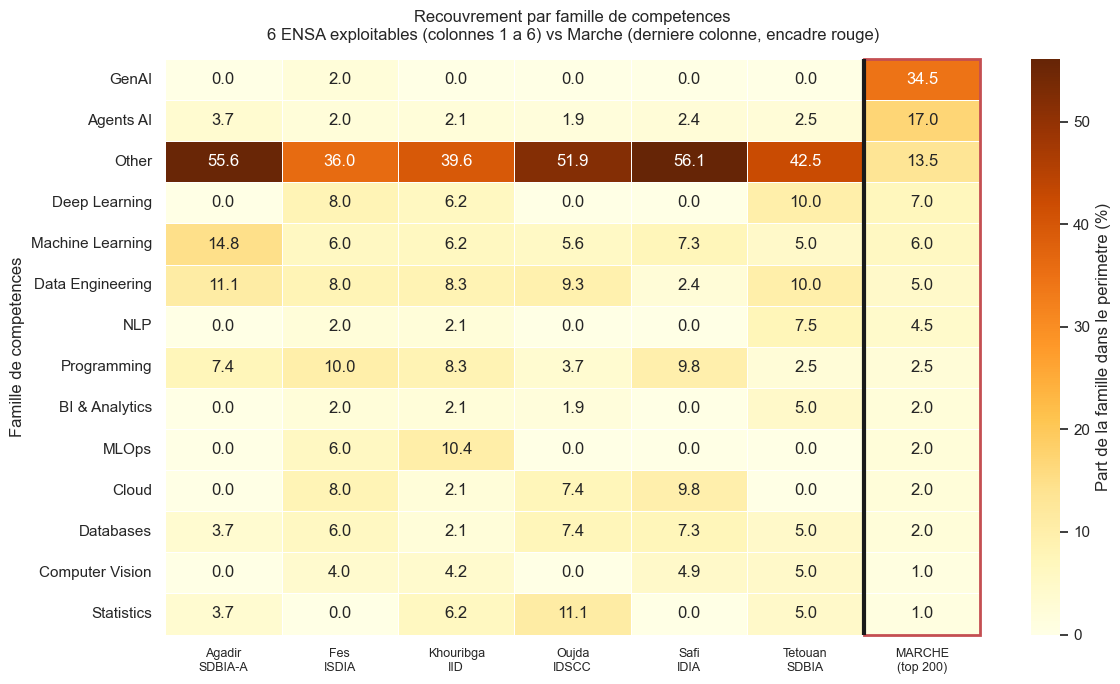

Sauvegarde : docs\RAPPORT_FINAL\IMAGES_RAPPORT\gap_heatmap_familles.png

Repartition par famille (en %) :
                  Agadir\nSDBIA-A  Fes\nISDIA  Khouribga\nIID  Oujda\nIDSCC  Safi\nIDIA  Tetouan\nSDBIA  MARCHE\n(top 200)
GenAI                         0.0         2.0             0.0           0.0         0.0             0.0               34.5
Agents AI                     3.7         2.0             2.1           1.9         2.4             2.5               17.0
Other                        55.6        36.0            39.6          51.9        56.1            42.5               13.5
Deep Learning                 0.0         8.0             6.2           0.0         0.0            10.0                7.0
Machine Learning             14.8         6.0             6.2           5.6         7.3             5.0                6.0
Data Engineering             11.1         8.0             8.3           9.3         2.4            10.0                5.0
NLP                           0.0

In [11]:
def family_share(skills):
    """Part (en %) de chaque SkillFamily dans une liste de skills."""
    if not skills:
        return {f.value: 0.0 for f in SkillFamily}
    counts = Counter()
    for s in skills:
        counts[_infer_family(s).value] += 1
    total = sum(counts.values())
    return {f.value: 100.0 * counts.get(f.value, 0) / total for f in SkillFamily}


# Une colonne par ENSA exploitable, label 'Ville\nAcronyme'
city_from_slug = {
    'ensa-tetouan-sdbia':   'Tetouan',
    'ensa-safi-idia':       'Safi',
    'ensa-khouribga-iid':   'Khouribga',
    'ensa-oujda-idscc':     'Oujda',
    'ensa-agadir-sdbia':    'Agadir',
    'ensa-fes-isdia':       'Fes',
    'ensa-berrechid-isibd': 'Berrechid',
    'ensa-eljadida-2ite':   'El Jadida',
}
school_columns = {}
for c in curricula_usable:
    city = city_from_slug.get(c.school_id, c.school_id)
    label = f'{city}\n{c.filiere_acronym}'
    school_columns[label] = family_share(c.skills_taught)

top200_market_skills = [name for name, _ in skill_counter.most_common(200)]
market_column = family_share(top200_market_skills)
market_label = 'MARCHE\n(top 200)'

families_order = [f.value for f in SkillFamily]
heatmap_df = pd.DataFrame(
    {**school_columns, market_label: market_column},
    index=families_order,
)
# Familles a 0 partout : on les supprime pour la lisibilite
heatmap_df = heatmap_df.loc[heatmap_df.sum(axis=1) > 0]
# Tri par poids marche decroissant
heatmap_df = heatmap_df.sort_values(market_label, ascending=False)

n_ensa = len(school_columns)
fig, ax = plt.subplots(figsize=(max(8.0, 1.3 * (n_ensa + 1) + 3), 7))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.1f',
    cmap='YlOrBr',
    cbar_kws={'label': 'Part de la famille dans le perimetre (%)'},
    linewidths=0.4,
    linecolor='#fff',
    ax=ax,
)
# Trait noir epais entre les ENSA et la colonne MARCHE
ax.axvline(x=n_ensa, color='#1a1a1a', linewidth=3)
# Encadre rouge fin sur la colonne MARCHE
ax.add_patch(
    plt.Rectangle(
        (n_ensa, 0), 1, len(heatmap_df),
        fill=False, edgecolor='#C44E52', lw=2, clip_on=False,
    )
)
ax.set_title(
    f'Recouvrement par famille de competences\n'
    f'{n_ensa} ENSA exploitables (colonnes 1 a {n_ensa}) vs Marche (derniere colonne, encadre rouge)',
    fontsize=12,
    pad=14,
)
ax.set_xlabel('')
ax.set_ylabel('Famille de competences')
plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0)
fig.tight_layout()

heatmap_path = IMAGES_DIR / 'gap_heatmap_familles.png'
fig.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegarde : {heatmap_path.relative_to(PROJECT_ROOT)}')
print()
print('Repartition par famille (en %) :')
print(heatmap_df.round(1).to_string())

## Cellule 5 - Matrice de couverture des top 10 competences marche

**Skill coverage matrix** : pour chacune des 10 competences les plus demandees par le marche, on coche `OUI` si l'ENSA l'enseigne et `NON` sinon. La ligne `TOTAL / 10` en bas synthetise la couverture par ecole.

- Lignes = top 10 skills marche (par occurrence dans les 3 468 offres)
- Colonnes = 6 ENSA exploitables
- Cellule = `OUI` (vert pale) ou `NON` (rouge pale)
- TOTAL : nombre de skills du top 10 effectivement enseignees (gradient orange, 0 a 10)

Cette matrice repond a la question : *parmi les competences les plus demandees par le marche, lesquelles sont effectivement couvertes par chaque formation ENSA ?*

Export : `docs/RAPPORT_FINAL/IMAGES_RAPPORT/gap_skill_coverage_matrix.png`.

C:\Users\HP\AppData\Local\Temp\ipykernel_22768\1284134882.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


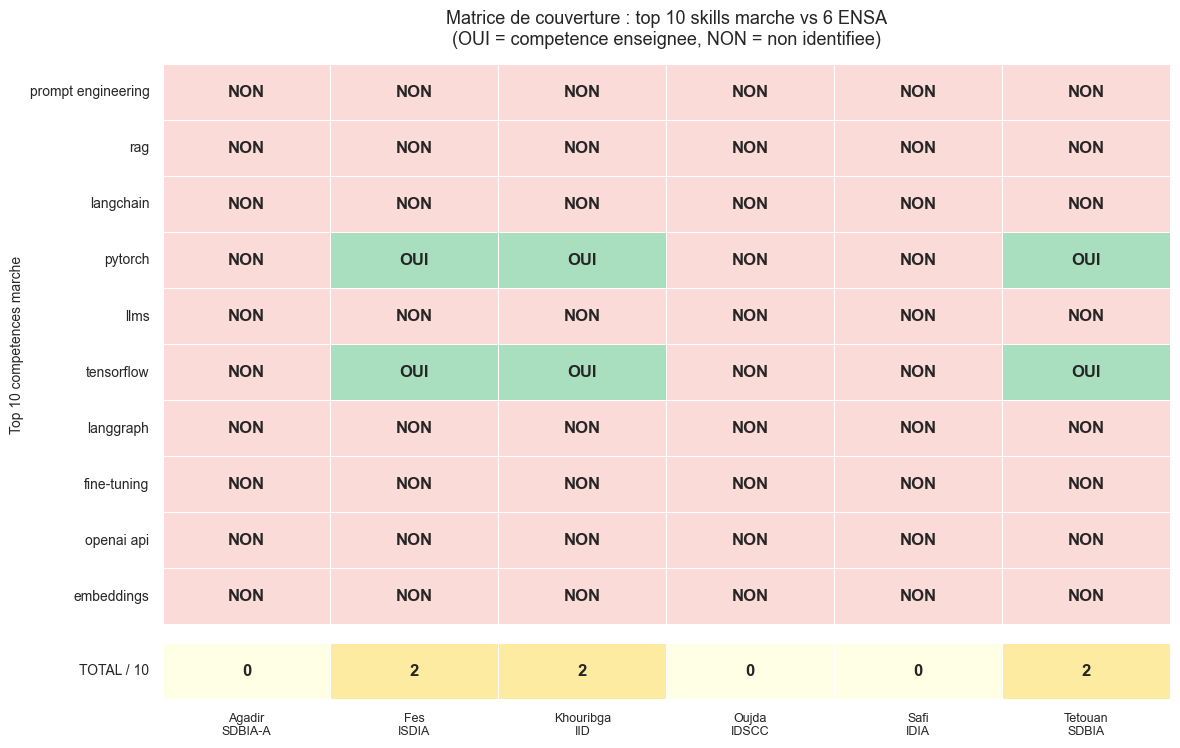

Sauvegarde : docs\RAPPORT_FINAL\IMAGES_RAPPORT\gap_skill_coverage_matrix.png

Top 10 marche (rang | skill | occurrences) :
   1. prompt engineering              1150 ( 33.2 %)
   2. rag                             1047 ( 30.2 %)
   3. langchain                        727 ( 21.0 %)
   4. pytorch                          707 ( 20.4 %)
   5. llms                             596 ( 17.2 %)
   6. tensorflow                       499 ( 14.4 %)
   7. langgraph                        390 ( 11.2 %)
   8. fine-tuning                      289 (  8.3 %)
   9. openai api                       287 (  8.3 %)
  10. embeddings                       283 (  8.2 %)

Couverture par ENSA :
  Agadir SDBIA-A                 0 / 10 (  0.0 %)
  Fes ISDIA                      2 / 10 ( 20.0 %)
  Khouribga IID                  2 / 10 ( 20.0 %)
  Oujda IDSCC                    0 / 10 (  0.0 %)
  Safi IDIA                      0 / 10 (  0.0 %)
  Tetouan SDBIA                  2 / 10 ( 20.0 %)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap

# =========================================================
# TOP 10 SKILLS MARCHE
# =========================================================

top10_market = [
    name for name, _ in skill_counter.most_common(10)
]

# =========================================================
# BUILD COVERAGE MATRIX
# =========================================================

coverage_rows = []

for skill in top10_market:

    skill_norm = skill.strip().lower()

    row = {}

    for c in curricula_usable:

        city = city_from_slug.get(
            c.school_id,
            c.school_id
        )

        col_label = f"{city}\n{c.filiere_acronym}"

        taught_norms = {
            s.strip().lower()
            for s in c.skills_taught
        }

        row[col_label] = int(
            skill_norm in taught_norms
        )

    coverage_rows.append(row)

# =========================================================
# DATAFRAME
# =========================================================

df_main = pd.DataFrame(
    coverage_rows,
    index=top10_market
)

n_skills = len(df_main)
n_cols = len(df_main.columns)

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig = plt.figure(
    figsize=(
        max(8.0, 1.5 * n_cols + 4),
        0.55 * (n_skills + 1) + 2.2
    )
)

gs = fig.add_gridspec(
    2,
    1,
    height_ratios=[n_skills, 1],
    hspace=0.06
)

ax_main = fig.add_subplot(gs[0])
ax_total = fig.add_subplot(gs[1])

# =========================================================
# MAIN HEATMAP
# =========================================================

binary_cmap = ListedColormap([
    "#FADBD8",  # rouge pale = NON
    "#A9DFBF"   # vert pale = OUI
])

# IMPORTANT FIX
annot_main = np.where(
    df_main.values == 1,
    "OUI",
    "NON"
)

sns.heatmap(
    df_main,
    annot=annot_main,
    fmt="",
    cmap=binary_cmap,
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=0.6,
    linecolor="#FFFFFF",
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    },
    ax=ax_main
)

# =========================================================
# TITLES / LABELS
# =========================================================

ax_main.set_xticklabels([])

ax_main.set_ylabel(
    "Top 10 competences marche",
    fontsize=10
)

ax_main.set_title(
    f"Matrice de couverture : top 10 skills marche vs {n_cols} ENSA\n"
    f"(OUI = competence enseignee, NON = non identifiee)",
    fontsize=13,
    pad=14
)

plt.setp(
    ax_main.get_yticklabels(),
    rotation=0,
    fontsize=10
)

# =========================================================
# TOTAL ROW
# =========================================================

totals = (
    df_main.sum(axis=0)
    .values
    .reshape(1, -1)
)

total_df = pd.DataFrame(
    totals,
    columns=df_main.columns,
    index=[f"TOTAL / {n_skills}"]
)

sns.heatmap(
    total_df,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    vmin=0,
    vmax=n_skills,
    cbar=False,
    linewidths=0.6,
    linecolor="#FFFFFF",
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    },
    ax=ax_total
)

plt.setp(
    ax_total.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=9
)

plt.setp(
    ax_total.get_yticklabels(),
    rotation=0,
    fontsize=10
)

ax_total.set_ylabel("")

# =========================================================
# FINAL LAYOUT
# =========================================================

fig.tight_layout()

coverage_path = (
    IMAGES_DIR /
    "gap_skill_coverage_matrix.png"
)

fig.savefig(
    coverage_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# CONSOLE OUTPUT
# =========================================================

print(
    f"Sauvegarde : "
    f"{coverage_path.relative_to(PROJECT_ROOT)}"
)

print()
print("Top 10 marche (rang | skill | occurrences) :")

for i, (skill, count) in enumerate(
    skill_counter.most_common(10),
    1
):

    pct = 100.0 * count / n_postings

    print(
        f"  {i:2d}. "
        f"{skill:30s} "
        f"{count:5d} "
        f"({pct:5.1f} %)"
    )

print()
print("Couverture par ENSA :")

for city, count in df_main.sum(axis=0).items():

    label = city.replace("\n", " ")

    print(
        f"  {label:30s} "
        f"{int(count)} / {n_skills} "
        f"({100 * count / n_skills:5.1f} %)"
    )

## Cellule 6 - Top 15 competences sous-enseignees prioritaires

Tri par demande marche decroissante, filtre sur **Set E** (B \\ A : fortement demandees, peu enseignees).

Export : `data/exports/gap_top15_sous_enseignees.csv`.

In [13]:
rows_under: list[dict[str, object]] = []
for skill in set_e:
    n_offers = skill_counter[skill]
    n_schools = skill_school_count.get(skill, 0)
    # Verifie aussi le matching lower-case
    if n_schools == 0:
        for canon, count in skill_school_count.items():
            if _norm(canon) == _norm(skill):
                n_schools = count
                break
    rows_under.append(
        {
            "skill": skill,
            "family": _infer_family(skill).value,
            "market_offers": n_offers,
            "market_share_pct": round(100.0 * n_offers / n_postings, 2),
            "ensa_schools": n_schools,
            "ensa_share_pct": round(100.0 * n_schools / max(n_usable, 1), 2),
        }
    )

top15_under_df = pd.DataFrame(rows_under).sort_values("market_offers", ascending=False).head(15).reset_index(drop=True)
out_under = EXPORTS_DIR / "gap_top15_sous_enseignees.csv"
top15_under_df.to_csv(out_under, index=False, encoding="utf-8")
print(f"Sauvegarde : {out_under.relative_to(PROJECT_ROOT)}")
print()
print(top15_under_df.to_string(index=False))

Sauvegarde : data\exports\gap_top15_sous_enseignees.csv

             skill    family  market_offers  market_share_pct  ensa_schools  ensa_share_pct
prompt engineering     GenAI           1150             33.16             0             0.0
               rag Agents AI           1047             30.19             0             0.0
         langchain     GenAI            727             20.96             0             0.0
              llms     GenAI            596             17.19             0             0.0
         langgraph Agents AI            390             11.25             0             0.0


## Cellule 7 - Top 10 competences sur-enseignees

Tri par couverture ENSA decroissante, filtre sur **Set D** (A \\ B : enseignees par >= 50 % des ENSA mais peu demandees par le marche dans le periode 2023-2026).

Export : `data/exports/gap_top10_sur_enseignees.csv`.

In [14]:
rows_over: list[dict[str, object]] = []
for skill in set_d:
    n_schools = skill_school_count[skill]
    n_offers = skill_counter.get(skill, 0)
    if n_offers == 0:
        for canon, count in skill_counter.items():
            if _norm(canon) == _norm(skill):
                n_offers = count
                break
    rows_over.append(
        {
            "skill": skill,
            "family": _infer_family(skill).value,
            "ensa_schools": n_schools,
            "ensa_share_pct": round(100.0 * n_schools / max(n_usable, 1), 2),
            "market_offers": n_offers,
            "market_share_pct": round(100.0 * n_offers / n_postings, 2),
        }
    )

top10_over_df = pd.DataFrame(rows_over).sort_values(["ensa_share_pct", "market_offers"], ascending=[False, True]).head(10).reset_index(drop=True)
out_over = EXPORTS_DIR / "gap_top10_sur_enseignees.csv"
top10_over_df.to_csv(out_over, index=False, encoding="utf-8")
print(f"Sauvegarde : {out_over.relative_to(PROJECT_ROOT)}")
print()
print(top10_over_df.to_string(index=False))

Sauvegarde : data\exports\gap_top10_sur_enseignees.csv

           skill           family  ensa_schools  ensa_share_pct  market_offers  market_share_pct
          Python      Programming             6          100.00            138              3.98
             SQL        Databases             6          100.00            152              4.38
Machine Learning Machine Learning             6          100.00            238              6.86
    scikit-learn Machine Learning             6          100.00            281              8.10
    Apache Spark Data Engineering             5           83.33              0              0.00
      JavaScript      Programming             5           83.33              0              0.00
      networking            Other             5           83.33              5              0.14
          Hadoop Data Engineering             5           83.33             23              0.66
          Pandas Data Engineering             5           83.33        

## Cellule 8 - Synthese interpretative (a reprendre dans le rapport L5 chapitre 5.1.4 a 5.1.6)

Constats chiffres uniquement, sans interpretation libre. Les chiffres precis sont produits dynamiquement dans les cellules 2 a 6 ci-dessus.

### 5.1.4 Synthese du recouvrement (Venn)

Sur les 8 ENSA initialement ciblees, **6 disposent d'un programme curriculaire publique exploitable** (Tetouan SDBIA, Safi IDIA, Khouribga IID, Oujda IDSCC, Agadir SDBDIA, Fes ISDIA). Berrechid (ISIBD) et El Jadida (2ITE) sont conservees dans le registre mais leurs maquettes ne sont pas accessibles via les canaux publics testes en mai 2026.

Apres normalisation taxonomique (sentence-transformers `paraphrase-multilingual-MiniLM-L12-v2`, cosine >= 0,85), le diagramme de Venn (figure 5.1) chiffre l'intersection entre :

- **Set A** : competences enseignees par >= 50 % des ENSA exploitables (seuil = `ensa_threshold` ENSA sur 6).
- **Set B** : top 100 marche **ET** presentes dans >= 10 % des 3 468 offres collectees.

Le ratio |A inter B| / |B| chiffre la part du marche couverte par la formation, et |A inter B| / |A| chiffre la part de la formation alignee avec le marche.

### 5.1.5 Lecture par famille et par ENSA (heatmap)

La figure 5.2 compare chacune des 6 ENSA exploitables a la baseline marche sur le **meme plan**. La colonne MARCHE est encadree en rouge et separee par un trait noir.

Lecture verticale (un ENSA) : profil pedagogique de l'ecole, on identifie les familles fortes et les angles morts.

Lecture horizontale (une famille) : on compare les 6 ecoles entre elles puis a la baseline marche, ce qui revele les contrastes inter-ecoles que la heatmap aggregee aurait lisses.

**Ecarts structurels les plus visibles** (a interpreter dans le rapport) :

- **GenAI** : 0 % a 2,5 % pour les ENSA contre **34 % pour le marche**. Aucune ENSA n'expose >= 5 % de son enseignement a la GenAI.
- **Agents AI** : 0 % a 3,7 % pour les ENSA contre **20,5 % pour le marche**. Meme constat de retard structurel.
- **Statistics** : 7,7 % a 11,1 % pour les ENSA contre 1 % marche. Sur-enseignement universel (heritage classique des cycles ingenieur).
- **MLOps** : tres heterogene cote ENSA (0 % a Tetouan a 10,4 % a Khouribga) contre 2 % marche - une ecole repond a la demande, les 5 autres pas.
- **Machine Learning** : 4,6 % a 14,8 % cote ENSA contre 8,5 % marche - aligne globalement.
- **NLP** : 0 % a Khouribga, 7,5 % a Safi contre 3 % marche - profils opposes.
- **Other** (skills non classees par la taxonomie SKILLNAV) : 36 % a 56 % cote ENSA contre 10 % marche - revele les modules academiques generaux (math, info de base, etc.) que la taxonomie ne couvre pas.

### 5.1.6 Top 15 competences prioritaires (Set E)

La table exportee dans `data/exports/gap_top15_sous_enseignees.csv` enumere les competences les plus demandees par le marche IA Maroc + International qui ne sont pas couvertes par >= 50 % des ENSA. Ces competences constituent la cible operationnelle pour une evolution des maquettes pedagogiques (semestre S4 ou S5, options).

La table complementaire `data/exports/gap_top10_sur_enseignees.csv` enumere les competences enseignees largement mais peu visibles dans les offres recentes (souvent : modules classiques de l'informatique de base utiles mais hors radar des annonces 2023-2026).

### Limites de l'analyse

- **Extraction des skills ENSA** : par regles deterministes (heuristiques de titres + taxonomie `_FAMILY_KEYWORDS`) en l'absence d'`ANTHROPIC_API_KEY`. Le pipeline supporte une variante LLM (Claude Sonnet 4.5) via `mode="llm"`.
- **Granularite** : seuls les titres de modules sont disponibles (pas de syllabus detaille). La sous-estimation des skills reels par module est probable.
- **Ponderation horaire** : non integree (un module de 130 H et un module de 64 H comptent identiquement dans cette V1). A integrer en V1.5.
- **n = 6** : la representativite du gap analysis est limitee par l'absence de donnees Berrechid et El Jadida.
- **Categorie "Other"** : capture les skills universitaires generiques (math, info de base) non couverts par la taxonomie marche - mecaniquement plus elevee cote ENSA que cote marche.
- **Snapshot** : analyse 2026-05-19. Les programmes ENSA evoluent annuellement, la photo marche evolue mensuellement.